### **Breakpoints**

In [ ]:
%%capture --no-stderr
%pip install --quiet -U langgraph langchain_openai langgraph_sdk langgraph-prebuilt

In [24]:
import os, openai
from dotenv import load_dotenv, find_dotenv
from langchain_openai import ChatOpenAI

_ = load_dotenv(find_dotenv())
openai.api_key = os.environ['OPENAI_API_KEY']

llm_model = 'gpt-4o'
chat = ChatOpenAI(model = llm_model)

#### **Breakpoints for human approval**

In [25]:
def multiply(a: int, b: int) -> int:
    '''Multiply a and b.

    Args:
        a: first int
        b: second int
    '''
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    '''Adds a and b.

    Args:
        a: first int
        b: second int
    '''
    return a + b

def divide(a: int, b: int) -> float:
    '''Divide a by b.

    Args:
        a: first int
        b: second int
    '''
    return a / b

tools = [add, multiply, divide]
llm_with_tools = chat.bind_tools(tools)

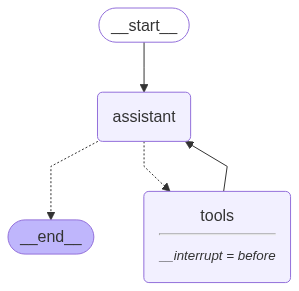

In [26]:
from IPython.display import Image, display

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition, ToolNode

from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

# System message
sys_msg = SystemMessage(content = 'You are a helpful assistant tasked with performing arithmetic on a set of inputs.')

# Node
def assistant(state: MessagesState):
   return {'messages': [llm_with_tools.invoke([sys_msg] + state['messages'])]}

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node('assistant', assistant)
builder.add_node('tools', ToolNode(tools))

# Define edges: these determine the control flow
builder.add_edge(START, 'assistant')
builder.add_conditional_edges(
    'assistant',
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge('tools', 'assistant')

memory = MemorySaver()
graph = builder.compile(interrupt_before = ['tools'], checkpointer = memory)

# Show
display(Image(graph.get_graph(xray = True).draw_mermaid_png()))


In [14]:
# Input
initial_input = {'messages': HumanMessage(content = 'Multiply 2 and 3')}

# Thread
thread = {'configurable': {'thread_id': '1'}}

# Run the graph until the first interruption
for event in graph.stream(initial_input, thread, stream_mode = 'values'):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (call_w3BZeNNVjcNkZy0O8s8uUTLo)
 Call ID: call_w3BZeNNVjcNkZy0O8s8uUTLo
  Args:
    a: 2
    b: 3


In [10]:
state = graph.get_state(thread)
state.next

('tools',)

Invoking the graph with `None` resumes execution from the last saved checkpoint.

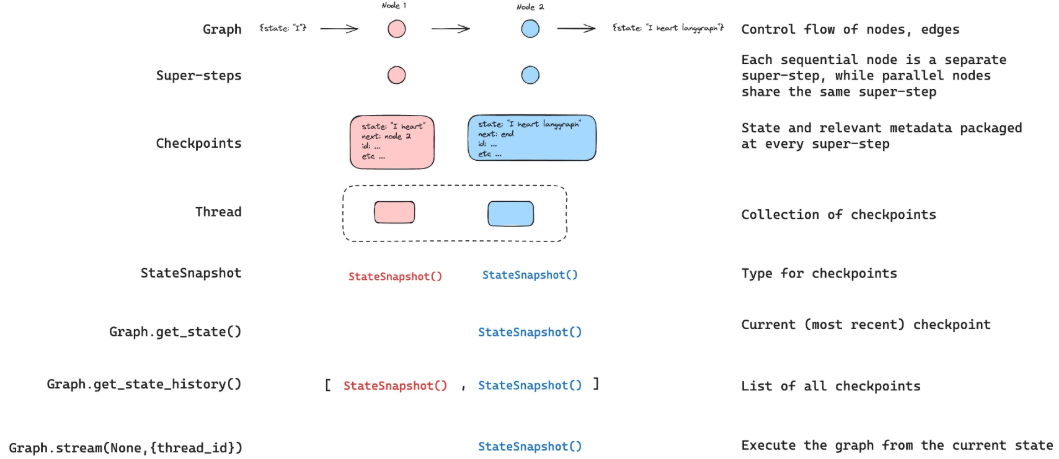

For clarity, LangGraph re-emits the current state containing the `AIMessage` with the tool call—before continuing execution. It then proceeds to the next step in the graph, beginning with the tool node. The tool is executed, and the result is returned to the chat model to generate the final response.

In [15]:
for event in graph.stream(None, thread, stream_mode = 'values'):
    event['messages'][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  multiply (call_w3BZeNNVjcNkZy0O8s8uUTLo)
 Call ID: call_w3BZeNNVjcNkZy0O8s8uUTLo
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

The result of multiplying 2 and 3 is 6.


In [27]:
# Input
initial_input = {"messages": HumanMessage(content="Multiply 2 and 3")}

# Thread
thread = {"configurable": {"thread_id": "2"}}

# Run the graph until the first interruption
for event in graph.stream(initial_input, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

# Get user feedback
user_approval = input("Do you want to call the tool? (yes/no): ")

# Check approval
if user_approval.lower() == "yes":
    
    # If approved, continue the graph execution
    for event in graph.stream(None, thread, stream_mode="values"):
        event['messages'][-1].pretty_print()
        
else:
    print("Operation cancelled by user.")

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (call_NjxHH0CytHrpDvPcsolwdfAr)
 Call ID: call_NjxHH0CytHrpDvPcsolwdfAr
  Args:
    a: 2
    b: 3
================================== Ai Message ==================================
Tool Calls:
  multiply (call_NjxHH0CytHrpDvPcsolwdfAr)
 Call ID: call_NjxHH0CytHrpDvPcsolwdfAr
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

The result of multiplying 2 and 3 is 6.


#### **Breakpoints with LangGraph API**

In [29]:
if 'google.colab' in str(get_ipython()):
    raise Exception("Unfortunately LangGraph Studio is currently not supported on Google Colab")

In [30]:
# This is the URL of the local development server
from langgraph_sdk import get_client
client = get_client(url="http://127.0.0.1:2024")

As shown above, we can add `interrupt_before=["node"]` when compiling the graph that is running in Studio.

However, with the API, you can also pass `interrupt_before` to the stream method directly.

In [ ]:
initial_input = {"messages": HumanMessage(content="Multiply 2 and 3")}
thread = await client.threads.create()
async for chunk in client.runs.stream(
    thread["thread_id"],
    assistant_id="agent",
    input=initial_input,
    stream_mode="values",
    interrupt_before=["tools"],
):
    print(f"Receiving new event of type: {chunk.event}...")
    messages = chunk.data.get('messages', [])
    if messages:
        print(messages[-1])
    print("-" * 50)